In [38]:
%pip install numpy matplotlib scipy tqdm torch


Note: you may need to restart the kernel to use updated packages.


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import tqdm
from scipy.interpolate import griddata

In [40]:
data = np.loadtxt(
    "data/muT_turbulent_plain_jet.txt",
    comments="%"
)


In [41]:
x = data[:, 0]
y = data[:, 1]
u = data[:, 2]
print(data.shape)
print(x.min(), x.max())
print(y.min(), y.max())
print(u.min(), u.max())

(100701, 3)
-0.4000000000000001 0.4
0.0 0.6000000000000001
0.00014310120756759787 92.79512132669105


In [42]:
x_grid = np.linspace(x.min(), x.max(), 100)
y_grid = np.linspace(y.min(), y.max(), 100)
x_grid, y_grid = np.meshgrid(x_grid, y_grid)
u_grid = griddata((x,y),u, (x_grid, y_grid), method = "nearest")   

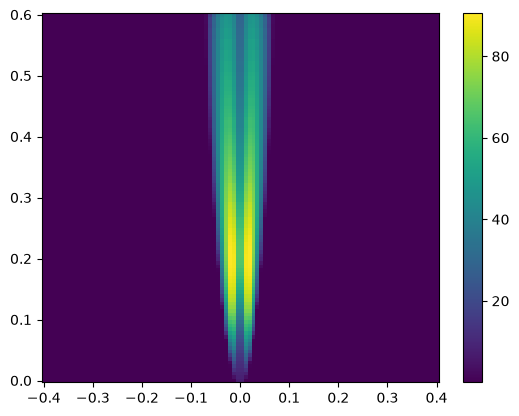

In [43]:
plt.pcolor(x_grid, y_grid, u_grid, shading="auto")
plt.colorbar()

In [44]:
# Нормализация всех признаков и целевой функции в диапазон [-1, 1].
def normalize_to_minus_one_one(values):
    values_min = values.min()
    values_max = values.max()
    return 2.0 * (values - values_min) / (values_max - values_min) - 1.0

x_norm = normalize_to_minus_one_one(x_grid)
y_norm = normalize_to_minus_one_one(y_grid)
u_norm = normalize_to_minus_one_one(u_grid)


In [45]:
u_grid.max()

np.float64(90.65160214128987)

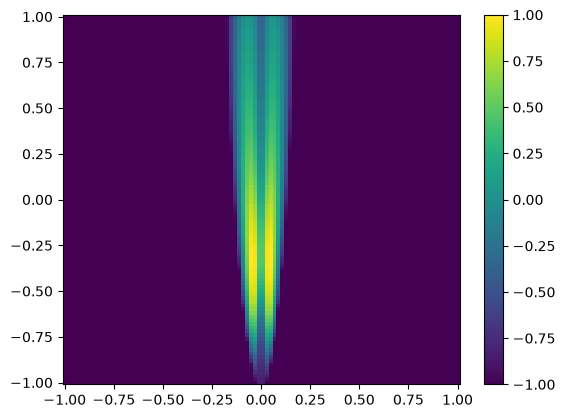

In [46]:

plt.pcolor(x_norm, y_norm, u_norm, shading="auto")
plt.colorbar()

Размер случайного входа: (4, 2)
Размер выхода модели: (4, 1)
Размер входных тензоров: (10000, 2)
Размер целевого тензора: (10000, 1)


Training: 100%|██████████| 100000/100000 [03:24<00:00, 489.66it/s, loss=9.364046e-06]


Начальный Loss: 1.564435e+00
Итоговый Loss: 9.430437e-06


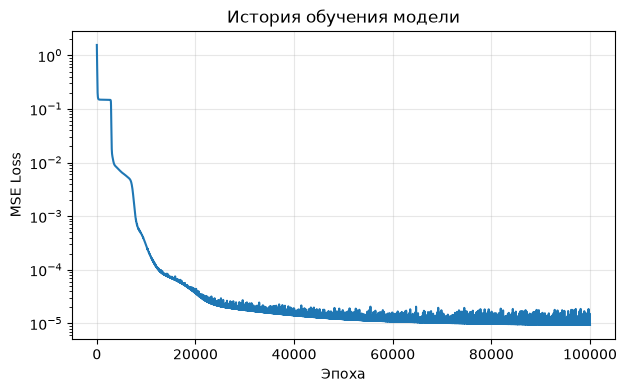

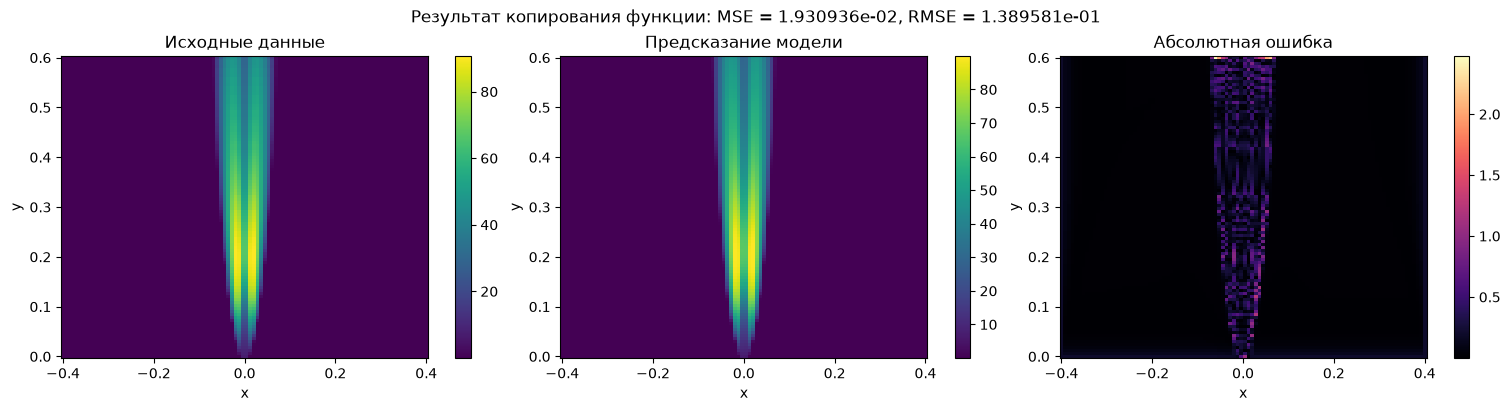

MSE: 1.930936e-02
RMSE: 1.389581e-01


In [47]:
# Пункты 5-10: модель, обучение и визуализация результата.

class PINNModel(nn.Module):
    def __init__(self, input_size=2, nnodes=5, output_size=1, nhlayers=4):
        super().__init__()
        self.activation = nn.Tanh()
        self.dense0 = nn.Linear(input_size, nnodes)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(nnodes, nnodes) for _ in range(nhlayers)]
        )
        self.output_layer = nn.Linear(nnodes, output_size)

    def forward(self, inputs):
        values = self.activation(self.dense0(inputs))
        for layer in self.hidden_layers:
            values = self.activation(layer(values))
        return self.activation(self.output_layer(values))


# Пункт 6: проверка модели на случайном тензоре.
torch.manual_seed(42)
model = PINNModel()
random_input = torch.rand(4, 2)
random_output = model(random_input)
print("Размер случайного входа:", tuple(random_input.shape))
print("Размер выхода модели:", tuple(random_output.shape))

# Пункт 7: подготовка обучающей выборки.
train_inputs = np.column_stack((x_norm.flatten(), y_norm.flatten())).astype(np.float32)
train_targets = u_norm.flatten().reshape(-1, 1).astype(np.float32)
train_inputs = torch.from_numpy(train_inputs)
train_targets = torch.from_numpy(train_targets)
print("Размер входных тензоров:", tuple(train_inputs.shape))
print("Размер целевого тензора:", tuple(train_targets.shape))

# Пункт 8: обучение и сохранение истории Loss.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 100000
hist_loss = []

progress = tqdm.tqdm(range(num_epochs), desc="Training")
for epoch in progress:
    optimizer.zero_grad()
    prediction = model(train_inputs)
    loss = nn.functional.mse_loss(prediction, train_targets)
    loss.backward()
    optimizer.step()
    current_loss = loss.item()
    hist_loss.append(current_loss)
    if epoch % 100 == 0:
        progress.set_postfix(loss=f"{current_loss:.6e}")

torch.save(model.state_dict(), "pinn_model_muT_turbulent_plain_jet.pth")
print(f"Начальный Loss: {hist_loss[0]:.6e}")
print(f"Итоговый Loss: {hist_loss[-1]:.6e}")

# Пункт 9: график обучения.
plt.figure(figsize=(7, 4))
plt.semilogy(hist_loss)
plt.xlabel("Эпоха")
plt.ylabel("MSE Loss")
plt.title("История обучения модели")
plt.grid(True, alpha=0.3)
plt.show()

# Пункт 10: исходная функция, предсказание и среднеквадратичная ошибка.
with torch.no_grad():
    predicted_norm = model(train_inputs).numpy().reshape(u_norm.shape)

u_min = u_grid.min()
u_max = u_grid.max()
predicted = (predicted_norm + 1.0) * (u_max - u_min) / 2.0 + u_min
mse = np.mean((predicted - u_grid) ** 2)
rmse = np.sqrt(mse)
error = np.abs(predicted - u_grid)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
plots = [
    (u_grid, "Исходные данные", "viridis"),
    (predicted, "Предсказание модели", "viridis"),
    (error, "Абсолютная ошибка", "magma"),
]
for axis, (values, title, cmap) in zip(axes, plots):
    image = axis.pcolormesh(x_grid, y_grid, values, shading="auto", cmap=cmap)
    axis.set_xlabel("x")
    axis.set_ylabel("y")
    axis.set_title(title)
    fig.colorbar(image, ax=axis)

fig.suptitle(f"Результат копирования функции: MSE = {mse:.6e}, RMSE = {rmse:.6e}")
plt.show()
print(f"MSE: {mse:.6e}")
print(f"RMSE: {rmse:.6e}")
